In [1]:
!pip install --quiet python-chess tensorflow numpy matplotlib

import chess
import chess.svg
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import random
import matplotlib.pyplot as plt
from collections import deque

print("TensorFlow Version:", tf.__version__)


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
D:\Sem8\Patent\src\preprocessing\.venv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


TensorFlow Version: 2.21.0


In [2]:
PIECE_TO_INDEX = {
    chess.PAWN: 0, chess.KNIGHT: 1, chess.BISHOP: 2,
    chess.ROOK: 3, chess.QUEEN: 4, chess.KING: 5
}

def board_to_matrix(board):
    """Converts a chess.Board state into a standard 8x8x12 numerical matrix."""
    matrix = np.zeros((8, 8, 12), dtype=np.float32)
    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece is not None:
            row = 7 - (square // 8)
            col = square % 8
            piece_idx = PIECE_TO_INDEX[piece.piece_type]
            if piece.color == chess.BLACK:
                piece_idx += 6
            matrix[row, col, piece_idx] = 1.0
    return matrix

In [3]:
class ChessDQN(tf.keras.Model):
    """Deep Q-Network predicting scalar positional evaluation values."""
    def __init__(self):
        super(ChessDQN, self).__init__()
        self.conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(8, 8, 12))
        self.conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')
        self.flatten = layers.Flatten()
        self.dense1 = layers.Dense(256, activation='relu')
        self.q_values = layers.Dense(1, activation='linear')

    def call(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.flatten(x)
        x = self.dense1(x)
        return self.q_values(x)

# Initialize Primary and Target networks for stable updates
model = ChessDQN()
target_model = ChessDQN()
target_model.set_weights(model.get_weights())
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Replay buffer to hold training transitions
memory = deque(maxlen=2000)

def select_best_move(net, board, epsilon):
    """Chooses a valid chess move using epsilon-greedy evaluation."""
    legal_moves = list(board.legal_moves)
    if not legal_moves:
        return None

    if random.random() < epsilon:
        return random.choice(legal_moves)

    best_move = None
    max_q = -float('inf')

    for move in legal_moves:
        board.push(move)
        state_matrix = np.expand_dims(board_to_matrix(board), axis=0)
        q_val = net(state_matrix).numpy()[0][0]
        board.pop()

        if q_val > max_q:
            max_q = q_val
            best_move = move

    return best_move if best_move else random.choice(legal_moves)

def calculate_reward(board):
    """Returns discrete termination rewards based on match outcomes."""
    if board.is_game_over():
        outcome = board.outcome()
        if outcome.winner == chess.WHITE:
            return 100.0
        elif outcome.winner == chess.BLACK:
            return -100.0
        return 0.0
    return 0.1

D:\Sem8\Patent\src\preprocessing\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
def perform_training_step(batch_size=32, gamma=0.95):
    """Samples from experience replay and runs backpropagation to update model weights."""
    if len(memory) < batch_size:
        return 0.0

    mini_batch = random.sample(memory, batch_size)
    states, targets = [], []

    for state, reward, next_state, done in mini_batch:
        states.append(state)
        target = reward
        if not done:
            next_state_tensor = np.expand_dims(next_state, axis=0)
            target += gamma * float(target_model(next_state_tensor)[0][0])
        targets.append([target])

    states = np.array(states, dtype=np.float32)
    targets = np.array(targets, dtype=np.float32)

    with tf.GradientTape() as tape:
        predictions = model(states)
        loss = tf.keras.losses.MeanSquaredError()(targets, predictions)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return float(loss)

In [5]:
epsilon = 1.0
epsilon_decay = 0.95
min_epsilon = 0.1
num_episodes = 10
episode_rewards = []

print("Beginning baseline agent training sequences...")
for episode in range(num_episodes):
    board = chess.Board()
    state = board_to_matrix(board)
    total_reward = 0

    while not board.is_game_over():
        move = select_best_move(model, board, epsilon)
        if move is None:
            break

        board.push(move)
        next_state = board_to_matrix(board)
        reward = calculate_reward(board)
        total_reward += reward

        # Store experience tuple
        memory.append((state, reward, next_state, board.is_game_over()))
        state = next_state

        # Execute training batch update step
        _ = perform_training_step(batch_size=16)

    # Periodically update the target network
    target_model.set_weights(model.get_weights())
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    episode_rewards.append(total_reward)
    print(f"Episode {episode+1}/{num_episodes} | Total Reward: {total_reward:.2f} | Epsilon: {epsilon:.2f}")

Beginning baseline agent training sequences...
Episode 1/10 | Total Reward: 52.30 | Epsilon: 0.95
Episode 2/10 | Total Reward: 35.30 | Epsilon: 0.90
Episode 3/10 | Total Reward: 44.60 | Epsilon: 0.86
Episode 4/10 | Total Reward: 43.10 | Epsilon: 0.81
Episode 5/10 | Total Reward: 53.70 | Epsilon: 0.77
Episode 6/10 | Total Reward: 111.60 | Epsilon: 0.74
Episode 7/10 | Total Reward: 43.30 | Epsilon: 0.70
Episode 8/10 | Total Reward: 28.90 | Epsilon: 0.66
Episode 9/10 | Total Reward: 61.10 | Epsilon: 0.63
Episode 10/10 | Total Reward: 61.90 | Epsilon: 0.60


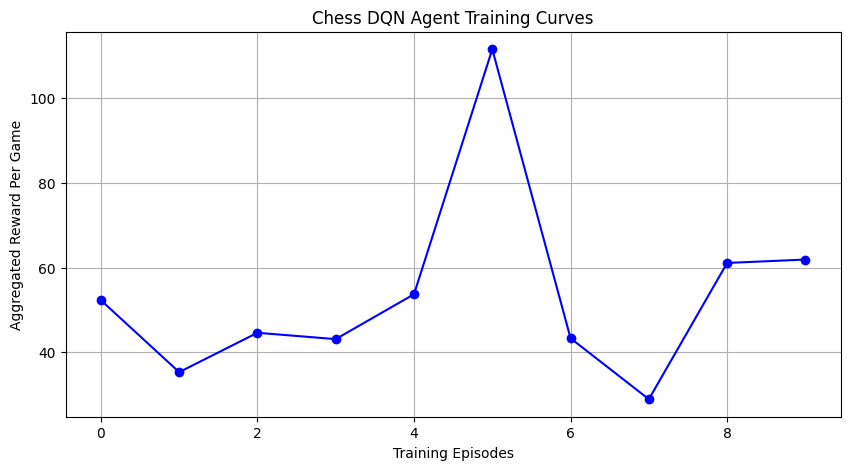

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, marker='o', color='b', linestyle='-')
plt.title('Chess DQN Agent Training Curves')
plt.xlabel('Training Episodes')
plt.ylabel('Aggregated Reward Per Game')
plt.grid(True)
plt.savefig('rewards_plot.png')
plt.show()

In [7]:
import tkinter as tk
from tkinter import messagebox
import chess
import numpy as np
import random  # Explicitly included for standalone cell execution stability

class InteractiveChessGUI:
    """A clickable Tkinter-based canvas window with fully synchronized coordinate mapping for White and Black sides."""
    def __init__(self, root, ai_model):
        self.root = root
        self.model = ai_model
        self.board = chess.Board()

        self.game_mode = self.prompt_game_mode()
        self.human_color = chess.WHITE
        if self.game_mode == "AI":
            self.human_color = self.prompt_color_selection()

        self.square_size = 70
        self.canvas = tk.Canvas(root, width=8 * self.square_size, height=8 * self.square_size)
        self.canvas.pack()

        self.selected_square = None
        self.legal_destinations = []
        self.canvas.bind("<Button-1>", self.on_square_click)

        self.light_square = "#eeeed2"
        self.dark_square = "#769656"
        self.highlight_color = "#baca44"
        self.dot_color = "#baca44"

        self.draw_board()

        if self.game_mode == "AI" and self.human_color == chess.BLACK:
            self.root.after(500, self.trigger_ai_move)

    def prompt_game_mode(self):
        mode = messagebox.askyesno("Game Mode", "Do you want to play against the AI?\n(Yes = Against AI, No = Player vs Player Local)")
        return "AI" if mode else "PvP"

    def prompt_color_selection(self):
        color_choice = messagebox.askyesno("Color Selection", "Do you want to play as White?")
        return chess.WHITE if color_choice else chess.BLACK

    def draw_board(self):
        self.canvas.delete("all")
        for row in range(8):
            for col in range(8):
                display_row = row if self.human_color == chess.WHITE else 7 - row
                display_col = col if self.human_color == chess.WHITE else 7 - col

                current_square = chess.square(display_col, 7 - display_row)
                color = self.highlight_color if self.selected_square == current_square else (self.light_square if (row + col) % 2 == 0 else self.dark_square)

                x1, y1 = display_col * self.square_size, display_row * self.square_size
                x2, y2 = x1 + self.square_size, y1 + self.square_size
                self.canvas.create_rectangle(x1, y1, x2, y2, fill=color, outline="")

        for square in chess.SQUARES:
            piece = self.board.piece_at(square)
            col, row = square % 8, 7 - (square // 8)
            display_row = (7 - row) if self.human_color == chess.WHITE else row
            display_col = col if self.human_color == chess.WHITE else 7 - col

            x = display_col * self.square_size + (self.square_size / 2)
            y = display_row * self.square_size + (self.square_size / 2)

            if square in self.legal_destinations:
                self.canvas.create_oval(x-8, y-8, x+8, y+8, fill="#a3c1ad", outline="")

            if piece is not None:
                text_color = "black" if piece.color == chess.BLACK else "white"
                outline_color = "white" if piece.color == chess.BLACK else "black"
                self.canvas.create_text(x, y, text=piece.unicode_symbol(), font=("Helvetica", 36), fill=outline_color)
                self.canvas.create_text(x, y, text=piece.unicode_symbol(), font=("Helvetica", 32), fill=text_color)

    def on_square_click(self, event):
        display_col = event.x // self.square_size
        display_row = event.y // self.square_size

        if self.human_color == chess.WHITE:
            col, row = display_col, 7 - display_row
        else:
            col, row = 7 - display_col, display_row

        clicked_square = chess.square(col, row)

        if self.game_mode == "AI" and self.board.turn != self.human_color:
            return

        if self.selected_square is None:
            piece = self.board.piece_at(clicked_square)
            if piece and piece.color == self.board.turn:
                self.selected_square = clicked_square
                self.legal_destinations = [move.to_square for move in self.board.legal_moves if move.from_square == clicked_square]
                self.draw_board()
        else:
            move = chess.Move(self.selected_square, clicked_square)
            if chess.Move(self.selected_square, clicked_square, chess.QUEEN) in self.board.legal_moves:
                move = chess.Move(self.selected_square, clicked_square, chess.QUEEN)

            if move in self.board.legal_moves:
                self.board.push(move)
                self.selected_square, self.legal_destinations = None, []
                self.draw_board()

                if not self.check_game_state() and self.game_mode == "AI":
                    self.root.after(500, self.trigger_ai_move)
            else:
                piece = self.board.piece_at(clicked_square)
                if piece and piece.color == self.board.turn:
                    self.selected_square = clicked_square
                    self.legal_destinations = [move.to_square for move in self.board.legal_moves if move.from_square == clicked_square]
                else:
                    self.selected_square, self.legal_destinations = None, []
                self.draw_board()

    def trigger_ai_move(self):
        legal_moves = list(self.board.legal_moves)
        if not legal_moves or self.board.is_game_over():
            return

        best_move = None
        max_q = -float('inf')

        for move in legal_moves:
            self.board.push(move)
            state_matrix = np.expand_dims(board_to_matrix(self.board), axis=0)
            q_val = self.model(state_matrix).numpy()[0][0]
            self.board.pop()

            if q_val > max_q:
                max_q = q_val
                best_move = move

        ai_choice = best_move if best_move else random.choice(legal_moves)
        self.board.push(ai_choice)
        self.draw_board()
        self.check_game_state()

    def check_game_state(self):
        if self.board.is_game_over():
            outcome = self.board.outcome().termination.name
            messagebox.showinfo("Game Over", f"Match terminated via: {outcome}")
            return True
        return False

def launch_playable_interface(trained_model):
    window = tk.Tk()
    window.title("ML-CaPsule Interactive Chess Engine")
    gui = InteractiveChessGUI(window, trained_model)
    window.mainloop()

# Launcher statement
launch_playable_interface(model)

In [8]:
import tkinter as tk
from tkinter import messagebox
import chess
import numpy as np
import random  # Explicitly included for standalone cell execution stability

class InteractiveChessGUI:
    """A clean, clickable Tkinter-based chess interface playing as White against the DQN AI agent."""
    def __init__(self, root, ai_model):
        self.root = root
        self.model = ai_model
        self.board = chess.Board()

        # Hardcoded defaults: No interactive prompts
        self.game_mode = "AI"
        self.human_color = chess.WHITE

        self.square_size = 70
        self.canvas = tk.Canvas(root, width=8 * self.square_size, height=8 * self.square_size)
        self.canvas.pack()

        self.selected_square = None
        self.canvas.bind("<Button-1>", self.on_square_click)

        # Color palettes matching standard repository visual guidelines
        self.light_square = "#eeeed2"
        self.dark_square = "#769656"
        self.highlight_color = "#baca44"

        self.draw_board()

    def draw_board(self):
        self.canvas.delete("all")

        # 1. Render rows and column matrix grids
        for row in range(8):
            for col in range(8):
                current_square = chess.square(col, 7 - row)

                if self.selected_square == current_square:
                    color = self.highlight_color
                else:
                    color = self.light_square if (row + col) % 2 == 0 else self.dark_square

                x1 = col * self.square_size
                y1 = row * self.square_size
                x2 = x1 + self.square_size
                y2 = y1 + self.square_size
                self.canvas.create_rectangle(x1, y1, x2, y2, fill=color, outline="")

        # 2. Render standard typographic unicode chess pieces
        for square in chess.SQUARES:
            piece = self.board.piece_at(square)
            col = square % 8
            row = 7 - (square // 8)

            x = col * self.square_size + (self.square_size / 2)
            y = row * self.square_size + (self.square_size / 2)

            if piece is not None:
                text_color = "black" if piece.color == chess.BLACK else "white"
                outline_color = "white" if piece.color == chess.BLACK else "black"

                self.canvas.create_text(
                    x, y, text=piece.unicode_symbol(),
                    font=("Helvetica", 36), fill=outline_color
                )
                self.canvas.create_text(
                    x, y, text=piece.unicode_symbol(),
                    font=("Helvetica", 32), fill=text_color
                )

    def on_square_click(self, event):
        col = event.x // self.square_size
        row = 7 - (event.y // self.square_size)
        clicked_square = chess.square(col, row)

        # Block human input click processing when it's the AI engine's turn
        if self.board.turn != self.human_color:
            return

        if self.selected_square is None:
            # Select piece if it belongs to the active human turn
            piece = self.board.piece_at(clicked_square)
            if piece and piece.color == self.board.turn:
                self.selected_square = clicked_square
                self.draw_board()
        else:
            move = chess.Move(self.selected_square, clicked_square)

            # Auto-promote to Queen to bypass native promotion selection boxes cleanly
            if chess.Move(self.selected_square, clicked_square, chess.QUEEN) in self.board.legal_moves:
                move = chess.Move(self.selected_square, clicked_square, chess.QUEEN)

            if move in self.board.legal_moves:
                self.board.push(move)
                self.selected_square = None
                self.draw_board()

                if not self.check_game_state():
                    self.root.after(500, self.trigger_ai_move)
            else:
                # If clicking a different piece of your own color, swap highlight focus cleanly
                piece = self.board.piece_at(clicked_square)
                if piece and piece.color == self.board.turn:
                    self.selected_square = clicked_square
                else:
                    self.selected_square = None
                self.draw_board()

    def trigger_ai_move(self):
        """The DQN steps through viable pathways and acts"""
        legal_moves = list(self.board.legal_moves)
        if not legal_moves or self.board.is_game_over():
            return

        best_move = None
        max_q = -float('inf')

        for move in legal_moves:
            self.board.push(move)
            state_matrix = np.expand_dims(board_to_matrix(self.board), axis=0)
            q_val = self.model(state_matrix).numpy()[0][0]
            self.board.pop()

            if q_val > max_q:
                max_q = q_val
                best_move = move

        ai_choice = best_move if best_move else random.choice(legal_moves)
        self.board.push(ai_choice)
        self.draw_board()
        self.check_game_state()

    def check_game_state(self):
        if self.board.is_game_over():
            outcome = self.board.outcome().termination.name
            messagebox.showinfo("Game Over", f"Match terminated via: {outcome}")
            return True
        return False

def launch_playable_interface(trained_model):
    window = tk.Tk()
    window.title("ML-CaPsule Interactive Chess Engine")
    gui = InteractiveChessGUI(window, trained_model)
    window.mainloop()

# Launcher statement
launch_playable_interface(model)